      f_res  max_power_dBm
0      3000          -54.0
1      3002          -54.1
2      3004          -54.0
3      3006          -53.9
4      3008          -53.8
...     ...            ...
996    4992          -63.8
997    4994          -63.3
998    4996          -63.3
999    4998          -63.8
1000   5000          -64.2

[1001 rows x 2 columns]


Text(0, 0.5, 'Power (dBm)')

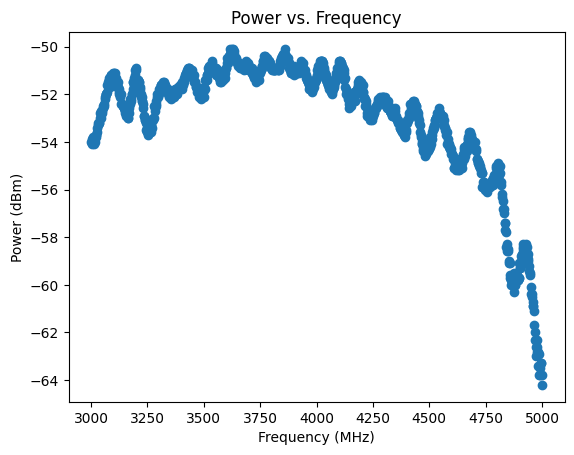

In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_csv('example_data_1_PHYS_433_533.csv')
print(df)

frequency = df['f_res']
power_dBm = df['max_power_dBm']

plt.scatter(frequency, power_dBm)
plt.title('Power vs. Frequency')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (dBm)')

[3.98107171e-06 3.89045145e-06 3.98107171e-06 4.07380278e-06
 4.16869383e-06]


Text(0, 0.5, 'Power (mW)')

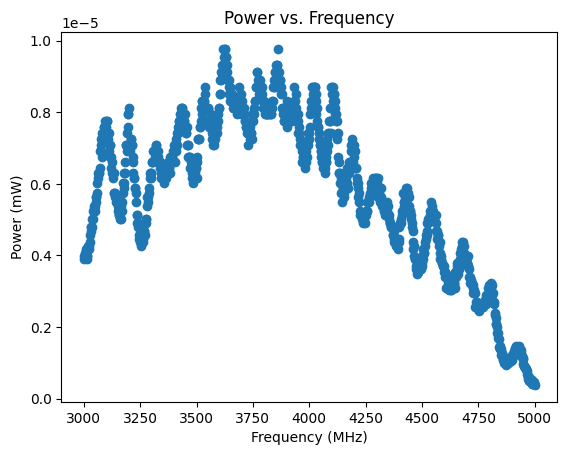

In [9]:
power_mW = 10** (np.array(power_dBm)/10)
print(power_mW[:5])

plt.scatter(frequency, power_mW)
plt.title('Power vs. Frequency')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (mW)')

Text(0, 0.5, 'Power (mW)')

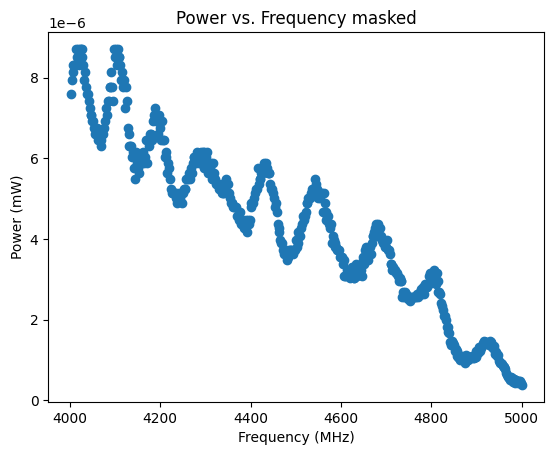

In [10]:
mask = frequency > 4000
frequency_filtered = frequency[mask]
power_mW_filtered = power_mW[mask]

plt.scatter(frequency_filtered, power_mW_filtered)
plt.title('Power vs. Frequency masked')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (mW)')

[[ 9.43181751e-21 -4.24526108e-17]
 [-4.24526108e-17  1.91865184e-13]]
y = -6.9385365239568575e-09x + 3.557312011980441e-05


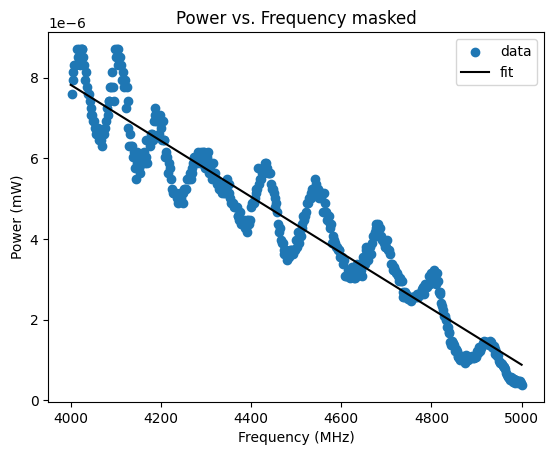

In [21]:
def linear_fit(x,m,b):
    return m*x+b

popt, pcov = curve_fit(linear_fit, frequency_filtered, power_mW_filtered,p0=[-1,0])
print(pcov)
slope = popt[0]
intercept = popt[1]
x_fit = np.linspace(4000,5000,100)

plt.scatter(frequency_filtered, power_mW_filtered,label='data')
plt.plot(x_fit,linear_fit(x_fit,slope,intercept),color='black',label='fit')
plt.title('Power vs. Frequency masked')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (mW)')
plt.legend()

print(f"y = {slope}x + {intercept}")